# EXPLORATORIO

# MCA Denoising Approach

## Contextualización

Se trabaja con dos transformadas 2D-1D que comparten el eje espectral y difieren solo en el espacial:

$$
\Phi_W = W^{2D} \otimes W^{1D} 
$$

$$
\Phi_C = C^{2D} \otimes W^{1D}
$$

La idea es compartir $W^{1D}$ y poner la diversidad morfológica en el eje espacial (puntual vs curvilíneo). Esto hace separables los componentes.

Entradas:
  - s          : cubo ruidoso  (Nx, Ny, Nλ)
  - $Φ_W$, $Φ_C$   : transformadas 2D-1D (análisis Φᵀ / síntesis Φ)
  - $σ_{k,b}$    : ruido por subbanda b de cada diccionario k   (Monte - Carlo / cubo negativo)
  - k_final    : umbral final en unidades de σ   (típico 3–4)
  - N_iter     : tope de iteraciones externas

Inicializar:
  - $s_W$ ← 0,  $s_C$ ← 0
  - s_coarse ← aproximación 2D-1D más gruesa de s        # NO se umbraliza (flujo)

Repetir t = 1 … N_iter:

  ### (1) Umbral MOM a partir del residuo total actual
  - E ← s − s_coarse − s_W − s_C
  - δ ← mean_{k∈{W,C}} (  ‖ (Φ_kᵀ E) / σ_{k,b} ‖_∞  )    # media de los máximos
  - δ ← max(δ, k_final)                                  # no bajar del piso

  ### (2) actualización por bloques, secuencial (Gauss–Seidel)
  - para k en {W, C}:
      - r_k ← s − s_coarse − Σ_{j≠k} s_j                 # residuo marginal (usa s_j ya actualizado)
      - α_k ← Φ_kᵀ r_k                                   # coeficientes por subbanda
      - α̃_k ← σ_{k,b} · SoftThresh_{δ}( α_k / σ_{k,b} )   # umbral por subbanda, en unidades de σ
      - α̃_k ← reweight(α̃_k)                              # (opcional) ℓ1 reponderado
      - s_k ← max( Φ_k α̃_k , 0 )                         # síntesis + positividad

  si  Var(E)  entra en meseta:  romper                 # criterio de parada

Salida:
  ŝ ← s_coarse + s_W + s_C
  componentes separadas:  s_W (isótropa),  s_C (anisótropa)

# 0. Importaciones y Configuración

In [23]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits

sys.path.append(os.path.abspath('../src'))

from mca_denoising import mca_denoise_cube, StarletTransform2D
from curvelets_denoising import reweighted_l1_denoise_cube
from wavelet_denoising import (
    Wavelet2D1DTransform,
    Denoiser2D1D
)

from dicts_wavelets import (
    transformaciones_1d,
    transformaciones_2d,
    filtros
)


In [24]:
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

# 1. Comparación con cubo sintético

In [25]:
rng = np.random.default_rng(0)

# --- cubo sintetico (n_chan, ny, nx) ---
n_chan, ny, nx = 48, 100, 100
yy, xx = np.mgrid[0:ny, 0:nx]

# estructura espacial ANISOTROPA: filamento curvo largo y delgado.
# Cresta y0(x) sinusoidal que cruza casi todo el campo, con ancho ~1 px:
# fuertemente anisotropa (la curvelet la representa con pocos atomos), a
# diferencia del arco compacto anterior (R=9, ancho 1.2) que a esa escala
# parecia un bulto isotropo y la starlet representaba igual de bien.
x0 = np.arange(nx)
ridge = ny / 2 + 22.0 * np.sin(2 * np.pi * (x0 - 10) / 130.0)
width = 1.0
filament = np.exp(-0.5 * ((yy - ridge[None, :]) / width) ** 2)

# perfil espectral: linea de emision gaussiana centrada en el canal 7
chans = np.arange(n_chan)
line = np.exp(-0.5 * ((chans - 7) / 1.5) ** 2)

clean = line[:, None, None] * filament[None, :, :]
clean /= clean.max()

# mas SNR que antes (sigma_noise=0.3 -> 0.15): el filamento debil debe
# sobrevivir al umbral para ejercitar de verdad la separacion anisotropa.
sigma_noise = 0.15
noisy = clean + sigma_noise * rng.standard_normal(clean.shape)

In [26]:
np.log2(len(chans))

np.float64(5.584962500721156)

In [27]:
# --- Denoising MCA: separa s_W (isotropa) y s_C (anisotropa) ---
res = mca_denoise_cube(
    noisy,
    n_spec_scales=int(np.log2(len(chans))),
    n_spatial_scales=None,
    k_final=3.0,
    max_iter=50,
    schedule="linear",
    floor_iters=5,
    curvelet_min_scale=0,
    positivity="estimate",
    ct_kwargs={"nbscales": 3, "nbangles_coarse": 3},
    reweight=True,
    calibrate=True,            # calibra sigma por propagacion de ruido en cada dict
    reference=clean,        # selecciona el mejor modelo por RMSE vs limpio
    ref_support_frac=0.05,  # RMSE de seleccion solo sobre el soporte de la senal
    verbose=True,
)

den = res["estimate"]
s_W = res["s_W"]
s_C = res["s_C"]
s_coarse = res["s_coarse"]


# --- comparación: Denoising 2D-1D W_2D (x) W_1D ---

denoiser_wavelets = Denoiser2D1D(
    transform_type=transformaciones_2d['TO_PAVE_BSPLINE'],
    transform_1d=transformaciones_1d['T01_MALLAT'],
    filter_2d=filtros['F_MALLAT_7_9'],
    filter_1d=filtros['F_MALLAT_7_9'],
    threshold_type='soft',
)

den_wavelets = denoiser_wavelets.denoise(
    method='iterative',
    x=noisy,
    y=noisy.copy(),
    threshold_level=5
)

result_wavelets = den_wavelets[0]

(*) Calibracion de ruido: sigma_global=1.4963e-01 | 2 diccionarios calibrados ([6, 19] subbandas).
(*) Seleccion por RMSE en soporte: 2857 voxeles (0.60% del cubo).
(*) lambda_max (MOM inicial)=25.089 -> desciende a k_final por dict [3.0, 3.0] en 50 iter.
iter  0 | deltaW=25.089 deltaC=25.089 | resid_var=2.178317e-02 | rel_change=nan | rmse_ref=1.787089e-01
iter  1 | deltaW=24.587 deltaC=24.587 | resid_var=2.178309e-02 | rel_change=3.63e-06 | rmse_ref=1.786960e-01
iter  2 | deltaW=24.085 deltaC=24.085 | resid_var=2.178303e-02 | rel_change=2.59e-06 | rmse_ref=1.786772e-01
iter  3 | deltaW=23.583 deltaC=23.583 | resid_var=2.178295e-02 | rel_change=3.80e-06 | rmse_ref=1.786489e-01
iter  4 | deltaW=23.081 deltaC=23.081 | resid_var=2.178286e-02 | rel_change=3.94e-06 | rmse_ref=1.786195e-01
iter  5 | deltaW=22.579 deltaC=22.579 | resid_var=2.178273e-02 | rel_change=6.00e-06 | rmse_ref=1.785744e-01
iter  6 | deltaW=22.077 deltaC=22.077 | resid_var=2.178257e-02 | rel_change=7.62e-06 | rmse_ref

In [28]:
print(f"RMSE ruidoso          vs limpio : {rmse(noisy, clean):.4f}")
print(f"RMSE Wavelets        vs limpio : {rmse(result_wavelets, clean):.4f}")
print(f"RMSE MCA            vs limpio : {rmse(den, clean):.6e}")

RMSE ruidoso          vs limpio : 0.1501
RMSE Wavelets        vs limpio : 0.0166
RMSE MCA            vs limpio : 2.672640e-02


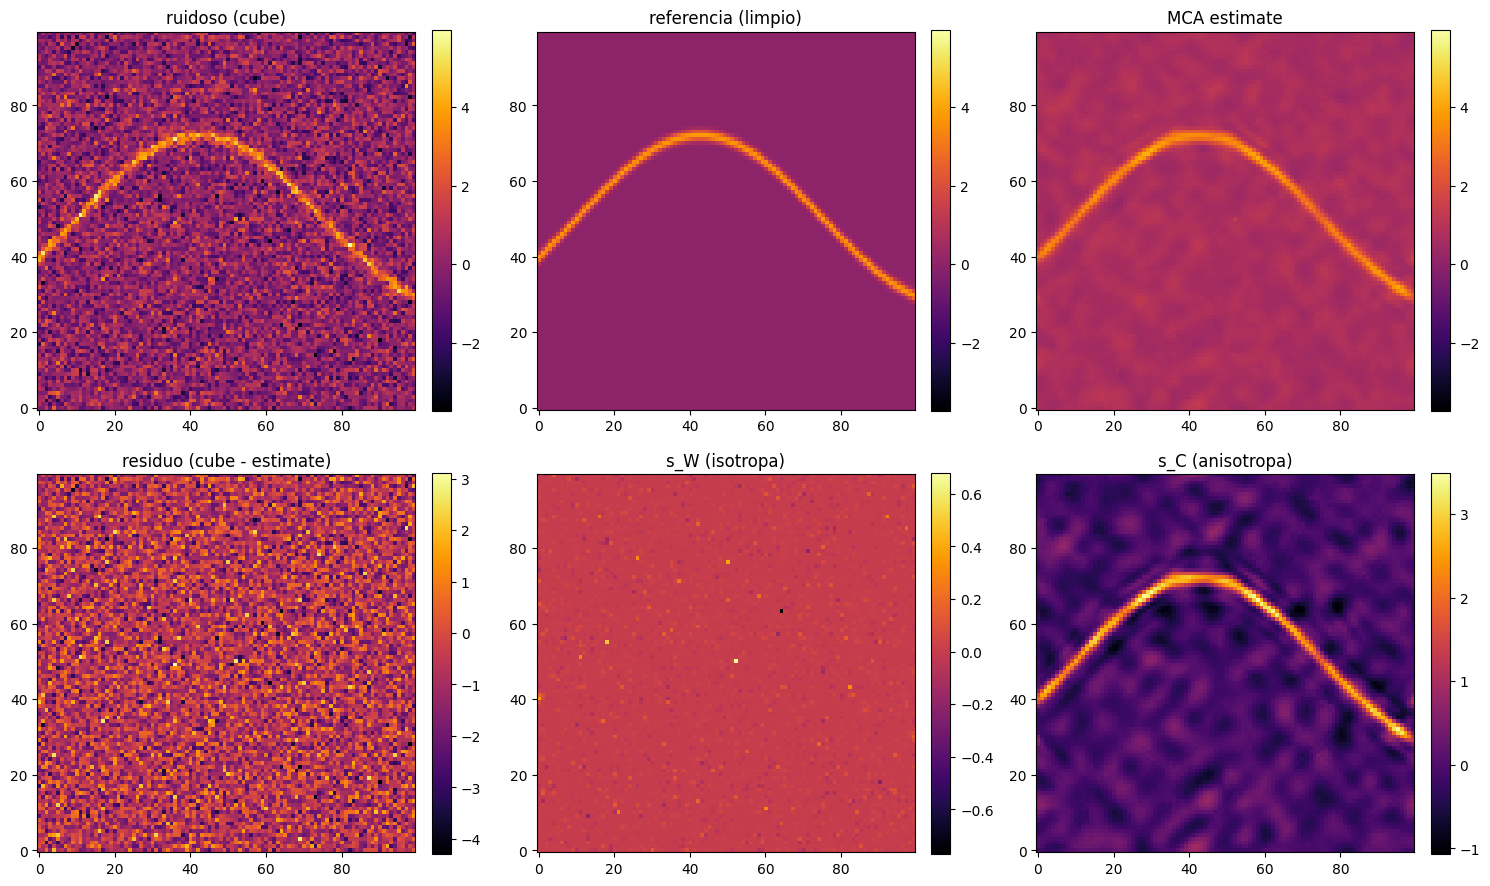

In [29]:
# --- Visualizacion: mapas de momento-0 ---
mom0 = lambda c: c.sum(axis=0)

panels = [
    (mom0(noisy),      "ruidoso (cube)"),
    (mom0(clean),  "referencia (limpio)"),
    (mom0(den),       "MCA estimate"),
    (mom0(res["residual"]), "residuo (cube - estimate)"),
    (mom0(s_W),       "s_W (isotropa)"),
    (mom0(s_C),       "s_C (anisotropa)"),
]

# escala compartida para cube / ref / estimate (comparacion justa)
shared = [mom0(noisy), mom0(clean), mom0(den)]
vmin = min(p.min() for p in shared)
vmax = max(p.max() for p in shared)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (data, title) in zip(axes.ravel(), panels):
    if title in ("residuo (cube - estimate)", "s_W (isotropa)", "s_C (anisotropa)"):
        im = ax.imshow(data, origin="lower", cmap="inferno")
    else:
        im = ax.imshow(data, origin="lower", vmin=vmin, vmax=vmax, cmap="inferno")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


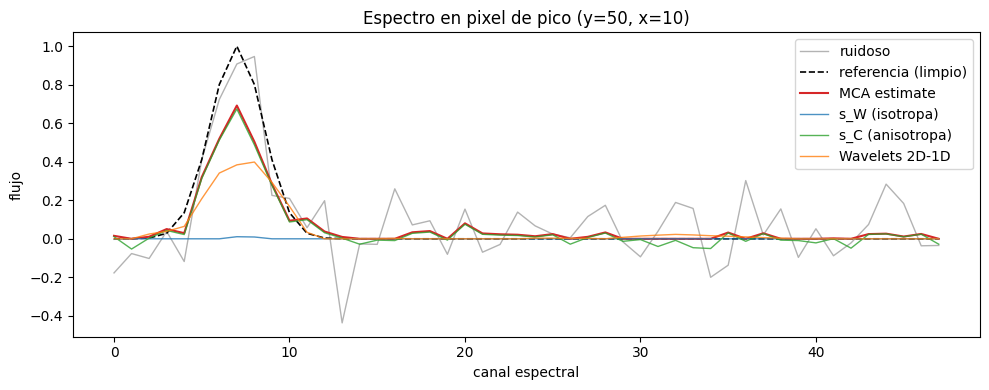

In [30]:
# --- Espectro en el pixel de pico: preserva el perfil de linea? ---
py, px = np.unravel_index(np.argmax(clean.sum(axis=0)), (ny, nx))
chan = np.arange(n_chan)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(chan, noisy[:, py, px], color="0.7", lw=1.0, label="ruidoso")
ax.plot(chan, clean[:, py, px], "k--", lw=1.2, label="referencia (limpio)")
ax.plot(chan, den[:, py, px], "C3", lw=1.5, label="MCA estimate")
ax.plot(chan, s_W[:, py, px], "C0", lw=1.0, alpha=0.8, label="s_W (isotropa)")
ax.plot(chan, s_C[:, py, px], "C2", lw=1.0, alpha=0.8, label="s_C (anisotropa)")
ax.plot(chan, result_wavelets[:, py, px], "C1", lw=1.0, alpha=0.8, label="Wavelets 2D-1D")
ax.set_xlabel("canal espectral")
ax.set_ylabel("flujo")
ax.set_title(f"Espectro en pixel de pico (y={py}, x={px})")
ax.legend()
plt.tight_layout()
plt.show()


# 2. Comparación general

In [16]:
# --- Carga del cubo (mismas rutas que EXP-curvelets_denoising) ---
DATA_DIR = '/Users/kuky/Documents/practica/WALDO/data'
CUBE_TYPE_DIR = 'mock_cubes'
CUBE_DIR = 'isolated_sub_AC5_N50_width1'

# cubo ruidoso
CUBE_NAME = 'isolated_sub_AC5_N50_width1_noisy_sub'
hdu = fits.open(os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME}.fits'))
cube = np.squeeze(hdu[0].data)
cube = np.nan_to_num(cube, nan=0.0)

# cubo limpio (referencia)
CUBE_NAME_REF = 'isolated_sub_AC5_N50_width1_notnoisy_sub'
hdu_ref = fits.open(os.path.join(DATA_DIR, CUBE_TYPE_DIR, CUBE_DIR, f'{CUBE_NAME_REF}.fits'))
cube_ref = np.squeeze(hdu_ref[0].data)
cube_ref = np.nan_to_num(cube_ref, nan=0.0)

n_chan, ny, nx = cube.shape
print(f"cube shape: {cube.shape}")


cube shape: (86, 200, 200)


In [18]:
# --- Denoising MCA: separa s_W (isotropa) y s_C (anisotropa) ---
# schedule='linear' (MCA clasico): el umbral baja desde lambda_max (MOM
# inicial) hasta el piso k_final, y refina floor_iters iteraciones en el piso.
# curvelet_min_scale=1: la curvelet NO usa su escala gruesa (lowpass isotropo);
#   las bajas frecuencias quedan en la starlet -> evita el anillamiento global.
# positivity='estimate': la no-negatividad se impone al estimate total, no a
#   cada componente, para que s_C no se rectifique en una rejilla de bultos.
res = mca_denoise_cube(
    cube,
    n_spec_scales=4,
    n_spatial_scales=None,
    k_final=3.0,
    max_iter=50,
    schedule="linear",
    floor_iters=5,
    curvelet_min_scale=1,
    positivity="estimate",
    ct_kwargs={"nbscales": 6, "nbangles_coarse": 3},
    reweight=True,
    calibrate=True,            # calibra sigma por propagacion de ruido en cada dict
    reference=cube_ref,        # selecciona el mejor modelo por RMSE vs limpio
    verbose=True,
)

den = res["estimate"]
s_W = res["s_W"]
s_C = res["s_C"]
s_coarse = res["s_coarse"]


(*) Calibracion de ruido: sigma_global=1.1098e-04 | 2 diccionarios calibrados ([7, 187] subbandas).
(*) lambda_max (MOM inicial)=220.128 -> desciende a k_final=3.0 en 50 iter.
iter  0 | delta=220.128 | resid_var=1.431040e-08 | rel_change=nan | rmse_ref=4.269726e-05
iter  1 | delta=215.697 | resid_var=1.442837e-08 | rel_change=8.24e-03 | rmse_ref=4.269726e-05
iter  2 | delta=211.266 | resid_var=1.442830e-08 | rel_change=4.32e-06 | rmse_ref=4.269726e-05
iter  3 | delta=206.835 | resid_var=1.442832e-08 | rel_change=8.72e-07 | rmse_ref=4.269726e-05
iter  4 | delta=202.403 | resid_var=1.442831e-08 | rel_change=6.12e-07 | rmse_ref=4.269726e-05
iter  5 | delta=197.972 | resid_var=1.442834e-08 | rel_change=2.37e-06 | rmse_ref=4.269726e-05
iter  6 | delta=193.541 | resid_var=1.442831e-08 | rel_change=1.92e-06 | rmse_ref=4.269726e-05
iter  7 | delta=189.110 | resid_var=1.442832e-08 | rel_change=3.11e-07 | rmse_ref=4.269726e-05
iter  8 | delta=184.679 | resid_var=1.442830e-08 | rel_change=1.58e-0

In [19]:
# --- Metricas RMSE vs limpio, con baseline solo-curvelet ---
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

# baseline: denoising solo con el camino curvelet (C_2D x W_1D)
den_curvelet = reweighted_l1_denoise_cube(
    cube,
    n_spec_scales=3,
    k_sigma=3.0,
    max_iter=15,
    ct_kwargs={"nbscales": 3, "nbangles_coarse": 3},
    reference=cube_ref,
    calibrate=True,
    verbose=False,
)

print(f"RMSE ruidoso        vs limpio : {rmse(cube, cube_ref):.6e}")
print(f"RMSE MCA            vs limpio : {rmse(den, cube_ref):.6e}")
print(f"RMSE solo-curvelet  vs limpio : {rmse(den_curvelet, cube_ref):.6e}")


RMSE ruidoso        vs limpio : 1.161957e-04
RMSE MCA            vs limpio : 4.269726e-05
RMSE solo-curvelet  vs limpio : 8.600037e-05


## Separación morfológica

Mapas de momento-0 (integral espectral) de las componentes separadas: `s_W` (isótropa, emisión puntual/extendida) y `s_C` (anisótropa, estructuras curvilíneas), junto al cubo ruidoso, la referencia limpia, la estimación MCA y el residuo.


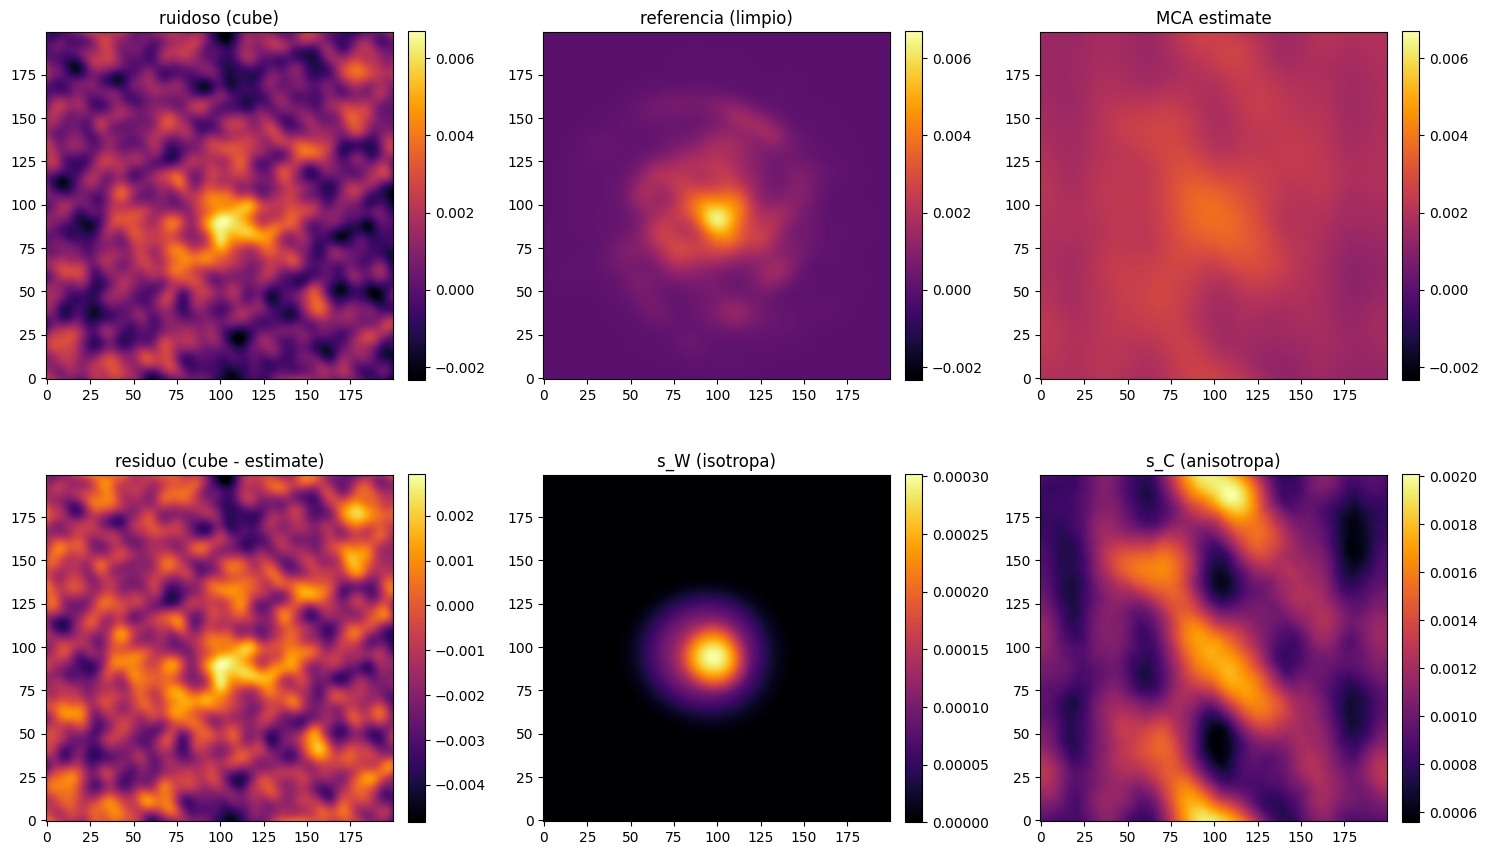

In [20]:
# --- Visualizacion: mapas de momento-0 ---
mom0 = lambda c: c.sum(axis=0)

panels = [
    (mom0(cube),      "ruidoso (cube)"),
    (mom0(cube_ref),  "referencia (limpio)"),
    (mom0(den),       "MCA estimate"),
    (mom0(res["residual"]), "residuo (cube - estimate)"),
    (mom0(s_W),       "s_W (isotropa)"),
    (mom0(s_C),       "s_C (anisotropa)"),
]

# escala compartida para cube / ref / estimate (comparacion justa)
shared = [mom0(cube), mom0(cube_ref), mom0(den)]
vmin = min(p.min() for p in shared)
vmax = max(p.max() for p in shared)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (data, title) in zip(axes.ravel(), panels):
    if title in ("residuo (cube - estimate)", "s_W (isotropa)", "s_C (anisotropa)"):
        im = ax.imshow(data, origin="lower", cmap="inferno")
    else:
        im = ax.imshow(data, origin="lower", vmin=vmin, vmax=vmax, cmap="inferno")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


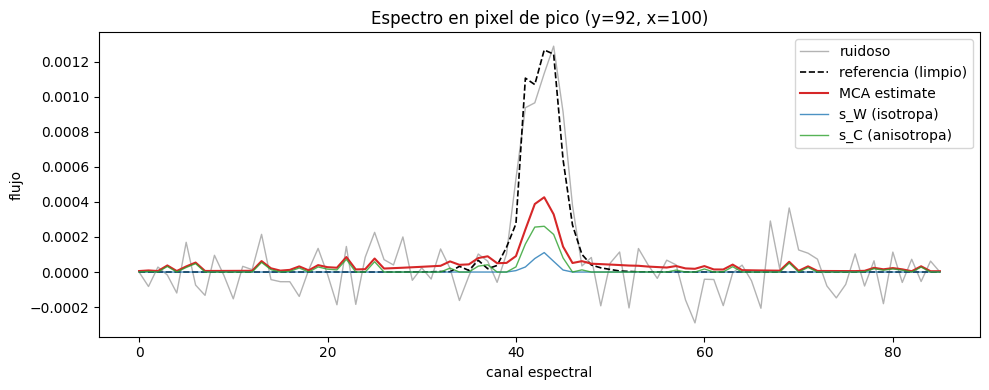

In [21]:
# --- Espectro en el pixel de pico: preserva el perfil de linea? ---
py, px = np.unravel_index(np.argmax(cube_ref.sum(axis=0)), (ny, nx))
chan = np.arange(n_chan)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(chan, cube[:, py, px], color="0.7", lw=1.0, label="ruidoso")
ax.plot(chan, cube_ref[:, py, px], "k--", lw=1.2, label="referencia (limpio)")
ax.plot(chan, den[:, py, px], "C3", lw=1.5, label="MCA estimate")
ax.plot(chan, s_W[:, py, px], "C0", lw=1.0, alpha=0.8, label="s_W (isotropa)")
ax.plot(chan, s_C[:, py, px], "C2", lw=1.0, alpha=0.8, label="s_C (anisotropa)")
ax.set_xlabel("canal espectral")
ax.set_ylabel("flujo")
ax.set_title(f"Espectro en pixel de pico (y={py}, x={px})")
ax.legend()
plt.tight_layout()
plt.show()


## Barrido de parámetros

La curvelet (frame redundante) suele dejar pasar grano de ruido a `k_final=3`, y con pocas escalas (`nbscales`) mezcla señal y ruido en la misma subbanda. Aquí se barre el piso del umbral de la curvelet `k_final_C` y el número de escalas `nbscales`, manteniendo `k_final_W=3` (la starlet representa la emisión isótropa de forma compacta y tolera un piso menor). Se reporta el RMSE vs limpio y se visualizan los paneles del mejor resultado.


In [ ]:
# --- Barrido: nbscales x curvelet_min_scale x k_final_C (k_final_W fijo en 3) ---
# curvelet_min_scale controla el confinamiento de la curvelet a escalas finas:
#   0 = usa el lowpass (puede dar anillamiento), 1 = sin lowpass, 2 = sin la
#   escala direccional mas gruesa. Es la palanca clave contra el patron global.
nbscales_grid = [6, 7]
min_scale_grid = [1, 2]
k_final_C_grid = [3.0, 4.0]

rmse_noisy = rmse(cube, cube_ref)
print(f"RMSE ruidoso vs limpio: {rmse_noisy:.6e}\n")

sweep = []
for nbsc in nbscales_grid:
    for mscale in min_scale_grid:
        for kfc in k_final_C_grid:
            r = mca_denoise_cube(
                cube,
                n_spec_scales=4,
                n_spatial_scales=4,
                k_final_W=3.0,
                k_final_C=kfc,
                max_iter=30,
                schedule="linear",
                floor_iters=5,
                curvelet_min_scale=mscale,
                positivity="estimate",
                ct_kwargs={"nbscales": nbsc, "nbangles_coarse": 6},
                calibrate=True,
                reference=cube_ref,
                verbose=False,
            )
            score = rmse(r["estimate"], cube_ref)
            sweep.append({
                "nbscales": nbsc, "min_scale": mscale, "k_final_C": kfc,
                "rmse": score, "flux_W": float(r["s_W"].sum()),
                "flux_C": float(r["s_C"].sum()), "res": r,
            })
            print(f"nbscales={nbsc} | min_scale={mscale} | k_final_C={kfc:<4} "
                  f"-> RMSE={score:.6e} | flux_W={sweep[-1]['flux_W']:.3e} "
                  f"flux_C={sweep[-1]['flux_C']:.3e}")

# mejor combinacion (menor RMSE)
best = min(sweep, key=lambda d: d["rmse"])
print(f"\nMejor: nbscales={best['nbscales']} min_scale={best['min_scale']} "
      f"k_final_C={best['k_final_C']} "
      f"-> RMSE={best['rmse']:.6e} (mejora vs ruidoso: "
      f"{100*(1-best['rmse']/rmse_noisy):.1f}%)")


In [ ]:
# --- Paneles del mejor resultado del barrido ---
rb = best["res"]
den_b, sW_b, sC_b = rb["estimate"], rb["s_W"], rb["s_C"]

panels_b = [
    (mom0(cube),            "ruidoso (cube)"),
    (mom0(cube_ref),        "referencia (limpio)"),
    (mom0(den_b),           f"MCA best (nbsc={best['nbscales']}, ms={best['min_scale']}, kC={best['k_final_C']})"),
    (mom0(rb["residual"]),  "residuo (cube - estimate)"),
    (mom0(sW_b),            "s_W (isotropa)"),
    (mom0(sC_b),            "s_C (anisotropa)"),
]

shared_b = [mom0(cube), mom0(cube_ref), mom0(den_b)]
vmin_b = min(p.min() for p in shared_b)
vmax_b = max(p.max() for p in shared_b)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (data, title) in zip(axes.ravel(), panels_b):
    if title.startswith(("residuo", "s_W", "s_C")):
        im = ax.imshow(data, origin="lower", cmap="inferno")
    else:
        im = ax.imshow(data, origin="lower", vmin=vmin_b, vmax=vmax_b, cmap="inferno")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
